# Improving our Eco-friendly Intelligent Agent
We are still improving on the design of Sammy the Spartan, our eco-friendly intelligent agent powered by carrots. 

Just like in the previous homework, we'll guide  Sammy in his quests to collect medals in a maze.  Sammy can only move North, South, West or East.  He is unable to move diagonally.  
Sammy's carrot consumption is determined by his moves' directions.  For example, Sammy will consume more carrots moving backwards (East) than forward (West).  Sammy will also consume more carrots moving North than South. The exact number of carrots consumed for each direction is specified in the _cost_ dictionary in the Problem class defined in the [spartanquest](./spartanquest.ipynb) notebook.

The various positions in the maze are represented as a tuple of x and y coordinates. The top left position is (0, 0). The x coordinate increases as we move right in the grid and the y coordinate increases as we move down in the grid - as shown below.
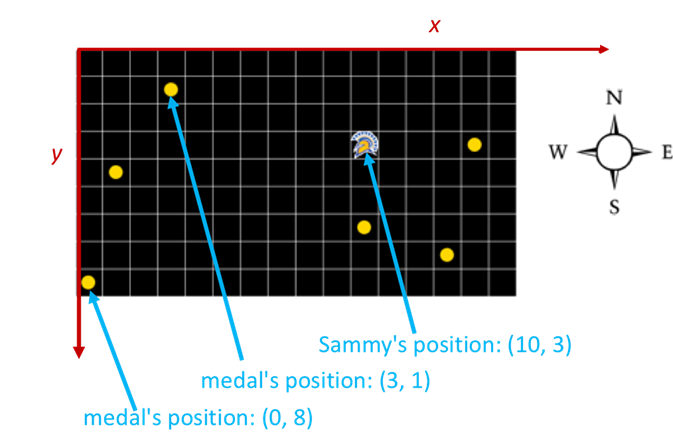

# Homework 2: Informed Search
Your task this week is to find more efficient ways to guide Sammy the Spartan on the optimal path in his quest in bigger and more complex mazes.

Just like in the previous assignment, the quest search problem has been formulated for you in the [spartanquest](./spartanquest.ipynb) notebook.  The data structures you need to use are defined for you in the [data_structures](./data_structures.ipynb) notebook.

In this notebook (informed_search), you'll implement the following functions:
1.  _astar_ (A* graph search algorithm)
2.  _single_heuristic_ and its helper function _manhattan_distance_
3.  _better_heuristic_ and its helper function _carrots_to_medal_
4.  _gen_heuristic_

This is the only notebook you need to submit when you complete your assignment.

Let's first import all we need before we get started. Make sure you run the code cell below everytime you start working on this notebook.

In [ ]:
%run spartanquest.ipynb
from data_structures import *

## 1. A* Search
### The null heuristic
The _null_heuristic_ is implemented for you in the code cell below.   

Make sure you run the code cell to define the function.

In [ ]:
def null_heuristic(state, problem):
    """
    Trivial heuristic to be used with A*.
    Running A* with this null heuristic, gives us uniform cost search
    :param
    state: A state is represented by a tuple containing:
                the current position of Sammy the Spartan
                a tuple containing the positions of the remaining medals
    problem: (a Problem object) representing the quest
    :return: 0
    """
    return 0

### A* Graph Search Implementation
Implement the A* graph search algorithm by filling in your code in the function _astar_ below.   
Use the Node class and one of the data structures defined in the [data_structures](./data_structures.ipynb) notebook to implement the fringe.  
Make sure you run the code cell after you fill in or modify your code.   

In [ ]:
def astar(problem, heuristic):
    """
    A* graph search algorithm
    returns a solution for the given search problem
    :param
    problem (a Problem object) representing the quest
            see Problem class definition in spartanquest.py
    heuristic (a function) the heuristic function to be used
    :return: list of actions representing the solution to the quest
                or None if there is no solution
    """
    # Enter your code here and remove the pass statement below
    closed = set()  # keep track of our explored states
    fringe = PriorityQueue() # for a*, the fringe is a priority queue
    state = problem.start_state()
    root = Node(state, None, None, 0)

    fringe.push(root, heuristic(state, problem)) 
    
    while not fringe.is_empty():
        node = fringe.pop()
        
        if problem.is_goal(node.state):
            return node.solution()  # we found a solution
            
        if node.state not in closed:  # we are implementing graph search
            closed.add(node.state)
            
            for child_state, action, action_cost in problem.expand(node.state):
                child_cost = action_cost + node.cumulative_cost
                child_node = Node(child_state, node, action, child_cost)
                total_cost = child_cost + heuristic(child_state, problem) # f = g + h
                fringe.push(child_node, total_cost)
    return None  # Failure -  no solution was found


Now you are ready to test your implementation.  
Note that when you run A* with the null heuristic, you should get the same results as with the uniform cost search: 

In [ ]:
gospartans("SJSU.txt", "astar", "null_heuristic")

## 2. Single Heuristic
Your task is to implement a heuristic based on the Manhattan distance, that can be used when we know for sure that there is only one medal in the quest.   
This heuristic is based on a very relaxed problem where there are no walls and all actions cost 1 carrot.  
The Manhattan Distance from Sammy to the single medal gives us the exact cost of this relaxed problem.  We can then use it as a heuristic/estimate for the harder problem.
Fill in  in your code in the functions _single_heuristic_ and _manhattan_distance_.  _single_heuristic_ should call _manhattan_distance_.

Remember to check whether the state passed is a goal state first (use the appropriate method from the Problem class).  What should the heuristic value be for a goal state?
  
To get any credit on this question,  your heuristic must be admissible and consistent.

In [ ]:
def manhattan_distance(point1, point2):
    """
    Compute the Manhattan distance between two points.
    :param point1 (tuple) representing the coordinates of a point in a plane
    :param point2 (tuple) representing the coordinates of a point in a plane
    :return: (integer)  The Manhattan distance between the two points
    """
    # Enter your code here and remove the pass statement below
    # |x2 - x1| + |y2 - y1|
    return abs(point2[0] - point1[0]) + abs(point2[1] - point1[1])


def single_heuristic(state, problem):
    """
    This heuristic can be used when we know for sure 
    that there is only one medal in the quest.
    :param
    state: A state is represented by a tuple containing:
                the current position of Sammy the Spartan
                a tuple containing the positions of the remaining medals
    problem: (a Problem object) representing the quest

    :return: (integer)
    """
    # Enter your code here and remove the pass statement below
    position, medals = state
    
    if problem.is_goal(state):
        return 0

    return manhattan_distance(position, medals[0])


A* with the _single_heuristic_ should find the optimal solution a little faster than A* with the _null_heuristic_ (effectively UCS) for the quest described in [questE.txt](./questE.txt) (353 nodes expanded vs 383). 

In [ ]:
gospartans("questE.txt", "astar", "single_heuristic")

## 3. Better Heuristic
Your task now is to implement a better heuristic to be used when we know for sure that there is only one medal in the quest.  
We saw that the _single_heuristic_ is based on two relaxations to the original problem.  Add back one of these relaxations to implement the _better_heuristic_.  
Fill in  in your code for the helper function _carrots_to_medal_ and the function _better_heuristic_ below.   
_better_heuristic_ should call _carrots_to_medal_.

**HINT**: The _problem_ parameter gives you access to the following class variables: problem.NORTH, problem.SOUTH, problem.EAST, problem.WEST and problem.cost.


To get any credit on this question, your heuristic must be admissible and consistent.

In [ ]:
def carrots_to_medal(sammy, medal, problem):
    """
    Compute the minimum number of carrots that Sammy consumes to reach the given
    medal  (assuming he does not take any unnecessary detours and there are no walls.)
    :param sammy (tuple) representing the position of Sammy in the grid
    :param medal (tuple) representing the position of a given medal
    :param problem (a Problem object) representing the quest
    :return: (integer) the number of carrots.
    """
    total_cost = 0
    dx = medal[0] - sammy[0]
    dy = medal[1] - sammy[1]

    if dx > 0:
        total_cost += dx * problem.cost[problem.EAST]
    else:
        total_cost += abs(dx) * problem.cost[problem.WEST]

    if dy > 0:
        total_cost += dy * problem.cost[problem.SOUTH]
    else:
        total_cost += abs(dy) * problem.cost[problem.NORTH]

    return total_cost
    
def better_heuristic(state, problem):
    """
    A heuristic based on a relaxed problem where there are no walls.
    The carrots_to_medal from Sammy to the single medal gives us the
    exact cost of this relaxed problem.
    :param
    state: A state is represented by a tuple containing:
               the current position of Sammy the Spartan
                a tuple containing the positions of the remaining medals
    problem: (a Problem object) representing the quest
    :return: (integer)
    """
    position, medals = state
    
    if problem.is_goal(state):
        return 0
        
    return carrots_to_medal(position, medals[0], problem)

A* with this better heuristic should find the optimal solution even faster for the quest described in [questE.txt](./questE.txt):  22 nodes expanded vs 353 for single_heuristic and 383 nodes for the null_heuristic (aka ucs). 

In [ ]:
gospartans("questE.txt", "astar", "better_heuristic")

## 4. General Heuristic
Your task now is to implement A more general heuristic to be used when the maze contains an arbitrary number of medals and these medals can be anywhere in the maze. Fill in your code in the function _gen_heuristic_. 

**HINTS**: One way to relax this complex problem is to assume that there is only one medal in the maze. For each medal you choose, you get a possible admissible heuristic.  How would you then pick the best one?  


Make sure you implementation is **memory and time efficient**: it does not store large data structures in memory and it does not perform unnecessary computations.

To get any credit on this question, your heuristic must be admissible and consistent.

In [ ]:
def gen_heuristic(state, problem):
    """
    A more general heuristic to be used when the maze contains an
    arbitrary number of medals and these medals can be anywhere in the maze.
    :param
    state: A state is represented by a tuple containing:
                the current position of Sammy the Spartan
                a tuple containing the positions of the remaining medals
    problem: (a Problem object) representing the quest
    :return: (Integer)
    """
    # Enter your code here and remove the pass statement below
    position, medals = state
    
    if problem.is_goal(state):
        return 0

    return max(carrots_to_medal(position, medal, problem) for medal in medals)

 A* with this general heuristic should find the optimal solution faster for the quest described in [questF.txt](./questF.txt).  Note that ucs expands 73,100 nodes for questF.txt. You will be graded based on how many nodes your heuristic expands.  My implementation expands 4,835 nodes. 


In [ ]:
gospartans("questF.txt", "astar", "gen_heuristic")

You should also be able to use _gen_heuristic_ to solve the quest described in [questG.txt](./questG.txt). within a reasonable time frame (about 3 seconds) and with fewer than 200,000 nodes expanded.  Note that the ucs solution to that same maze expands over 2 million nodes.

In [ ]:
gospartans("questG.txt", "astar", "gen_heuristic")

You should test your heuristic with ALL the quests provided.  Make sure that you are getting the optimal solution in all these cases.  If you get a solution that is non optimal, this is an indication that your heuristic is not admissible or not consistent.

In [ ]:
gospartans("questH.txt", "astar", "gen_heuristic")

In [ ]:
gospartans("questA.txt", "astar", "gen_heuristic")

In [ ]:
gospartans("questB.txt", "astar", "gen_heuristic")

In [ ]:
gospartans("questC.txt", "astar", "gen_heuristic")

In [ ]:
gospartans("questD.txt", "astar", "gen_heuristic")

In [ ]:
gospartans("SJSU.txt", "astar", "gen_heuristic")